# Extended Kalman Filter: Cart-Pole State Estimation

## Learning Objectives

- Apply the EKF to a **4-dimensional** state system (cart-pole)
- Demonstrate that the generic EKF predict/update functions from the pendulum work **unchanged** on a more complex system
- Handle **unmeasured states**: estimate velocities from position-only measurements
- Understand **observability**: when and why the EKF can infer states it cannot directly measure

## What's New vs. the Pendulum?

In Notebook 01, we tracked a 2-state pendulum (angle + velocity). Now we step up to a cart-pole: a cart that slides along a rail with a pendulum attached. The state vector doubles in size:

$$\mathbf{x} = \begin{bmatrix} x_{\text{cart}} \\ \dot{x}_{\text{cart}} \\ \theta \\ \dot{\theta} \end{bmatrix} \quad \text{(4 states)}$$

| Index | State | Description |
|-------|-------|-------------|
| 0 | $x_{\text{cart}}$ | Cart position along the rail (m) |
| 1 | $\dot{x}_{\text{cart}}$ | Cart velocity (m/s) |
| 2 | $\theta$ | Pole angle from hanging-down vertical (rad) |
| 3 | $\dot{\theta}$ | Pole angular velocity (rad/s) |

The dynamics are **coupled**: the pole's swing affects the cart's motion, and vice versa. This is more physically realistic and sets the stage for the key challenge of this notebook -- **partial observability**.

## Section 2: Setup

We import the same libraries as Notebook 01 and load the cart-pole MuJoCo model.

In [4]:
import dms
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import mediapy as media
from scipy.optimize import approx_fprime
import ipywidgets
from ipywidgets import interact_manual, FloatLogSlider

# Load the cart-pole model
model_path = dms.get_asset_path("mujoco_models/cartpole.xml")
model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

print(f'Model loaded: {model.nq} position DOFs, {model.nv} velocity DOFs')
print(f'Timestep: {model.opt.timestep} s')
print(f'Gravity: {model.opt.gravity}')

Model loaded: 2 position DOFs, 2 velocity DOFs
Timestep: 0.002 s
Gravity: [ 0.    0.   -9.81]


## Section 3: Cart-Pole Simulation

The cart-pole consists of a cart constrained to slide horizontally along a rail and a pole attached to the cart by a hinge joint. Unlike two independent systems, the cart and pole are **coupled**: when the pole swings, it exerts forces on the cart (and vice versa). This coupling is what makes the dynamics interesting and what the EKF must capture in its process model.

We simulate 5 seconds of free (unactuated) dynamics with the pole initially displaced from vertical. The cart is free to slide, so when the pole swings, the cart moves in response -- conservation of momentum in action.

In [ ]:
# Simulation parameters
duration = 5.0       # seconds
framerate = 30       # Hz for video capture
dt = model.opt.timestep  # 0.002 s

# Reset and set initial conditions
mujoco.mj_resetData(model, data)
data.qpos[0] = 0.0    # Cart centered on rail
data.qpos[1] = 0.5    # Pole displaced ~29 degrees from hanging-down
data.qvel[0] = 0.0    # Cart at rest
data.qvel[1] = 0.0    # Pole at rest
mujoco.mj_forward(model, data)  # Compute initial derived quantities

# State vector convention: x = [x_cart, x_dot, theta, theta_dot]^T
# MuJoCo mapping: x[0] = qpos[0], x[1] = qvel[0], x[2] = qpos[1], x[3] = qvel[1]
true_states = []   # List of (4,1) column vectors
times = []         # Time values
frames = []        # Video frames

# Run simulation
renderer = mujoco.Renderer(model, height=480, width=640)
cam=dms.mujoco.make_camera(model)
while data.time < duration:
    # Store ground truth BEFORE stepping (use .copy() to avoid MuJoCo buffer mutation)
    state = np.array([[data.qpos[0].copy()],   # x_cart
                      [data.qvel[0].copy()],   # x_dot
                      [data.qpos[1].copy()],   # theta
                      [data.qvel[1].copy()]])  # theta_dot
    true_states.append(state)
    times.append(data.time)

    # Capture video frame at desired framerate
    if len(frames) < data.time * framerate:
        renderer.update_scene(data, camera=cam)
        frames.append(renderer.render().copy())

    # Step physics
    mujoco.mj_step(model, data)

times = np.array(times)
print(f'Simulation complete: {len(true_states)} timesteps, {len(frames)} video frames')
print(f'Time range: {times[0]:.3f} to {times[-1]:.3f} s')
print(f'State shape: {true_states[0].shape} (4x1 column vector)')
print(f'Final cart position: {true_states[-1][0,0]:.4f} m')
print(f'Final pole angle: {true_states[-1][2,0]:.4f} rad')
renderer.close()

Simulation complete: 2501 timesteps, 150 video frames
Time range: 0.000 to 5.000 s
State shape: (4, 1) (4x1 column vector)
Final cart position: -0.0000 m
Final pole angle: -0.1822 rad


In [6]:
# Display cart-pole simulation video
media.show_video(frames, fps=framerate)

This browser does not support the video tag.


## Section 4: Cart-Pole Dynamics Model

The EKF needs a mathematical model to predict how the state evolves. For the cart-pole, the physics are richer than the pendulum: two coupled second-order differential equations describe how gravitational torque on the pole, inertial forces from the cart's motion, and damping all interact.

We use a **simplified point-mass approximation** for the pole (all mass concentrated at the tip). This intentionally does not match MuJoCo's physics exactly -- MuJoCo models the pole as a distributed-mass capsule with its own inertia tensor. The resulting **model mismatch** is actually pedagogically valuable: it demonstrates that the EKF works even when the process model is approximate, and the Q matrix accounts for this modeling uncertainty.

### Physical Parameters

| Parameter | Symbol | Value | Notes |
|-----------|--------|-------|-------|
| Cart mass | $M_c$ | 1.0 kg | Matches MuJoCo cart geom |
| Pole mass (point mass) | $m_p$ | 0.2 kg | Approximation of rod + tip |
| Pole length | $l$ | 0.6 m | Matches pole geom length |
| Cart damping | $b_c$ | 0.1 N s/m | Matches joint damping |
| Pole damping | $b_p$ | 0.01 N m s/rad | Matches joint damping |
| Gravity | $g$ | 9.81 m/s$^2$ | Standard |

### Equations of Motion

With $\theta = 0$ meaning the pole hangs straight down (same convention as Notebook 01), the unactuated equations of motion in solved form are:

$$\ddot{x} = \frac{m_p \sin\theta (l \dot{\theta}^2 + g \cos\theta) - b_c \dot{x}}{M_c + m_p \sin^2\theta}$$

$$\ddot{\theta} = \frac{-(M_c + m_p) g \sin\theta - m_p l \dot{\theta}^2 \sin\theta \cos\theta - b_c \dot{x} \cos\theta - \frac{(M_c + m_p) b_p \dot{\theta}}{m_p l}}{l (M_c + m_p \sin^2\theta)}$$

We discretize with Euler integration: positions step by velocity, velocities step by acceleration.

In [70]:
# Physical parameters (must match cartpole.xml)
M_c = 1.0    # cart mass (kg)
m_p = 0.2    # pole mass (kg) -- point mass approximation
l = 0.6      # pole length (m)
b_c = 0.1    # cart damping (N*s/m)
b_p = 0.01   # pole damping (N*m*s/rad)
g = 9.81     # gravity (m/s^2)


def cartpole_f(x, dt):
    """
    State transition function: x_{k+1} = f(x_k, dt).
    
    x: (4,1) state vector [x_cart, x_dot, theta, theta_dot]^T
    dt: time step (seconds)
    Returns: (4,1) predicted state
    """
    x_cart    = x[0, 0]
    x_dot     = x[1, 0]
    theta     = x[2, 0]
    theta_dot = x[3, 0]

    sin_t = np.sin(theta)
    cos_t = np.cos(theta)

    # Common denominator for both accelerations
    denom = M_c + m_p * sin_t**2

    # Cart acceleration (no external force, unactuated)
    x_ddot = (m_p * sin_t * (l * theta_dot**2 + g * cos_t) - b_c * x_dot) / denom

    # Pole angular acceleration
    theta_ddot = (-(M_c + m_p) * g * sin_t
                  - m_p * l * theta_dot**2 * sin_t * cos_t
                  - b_c * x_dot * cos_t
                  - (M_c + m_p) * b_p * theta_dot / (m_p * l)) / (l * denom)

    # Euler integration
    x_cart_new    = x_cart + dt * x_dot
    x_dot_new     = x_dot + dt * x_ddot
    theta_new     = theta + dt * theta_dot
    theta_dot_new = theta_dot + dt * theta_ddot

    return np.array([[x_cart_new], [x_dot_new], [theta_new], [theta_dot_new]])


# Quick sanity check
x_test = np.array([[0.0], [0.0], [0.5], [0.0]])
x_next = cartpole_f(x_test, dt)
print(f'Test state:     {x_test.T}')
print(f'Predicted next: {x_next.T}')
print(f'\nAt theta=0.5 rad with cart at rest:')
print(f'  Cart accelerates slightly (pole pulls it)')
print(f'  Pole accelerates back toward hanging position (gravity restoring)')

Test state:     [[0.  0.  0.5 0. ]]
Predicted next: [[ 0.      0.0016  0.5    -0.018 ]]

At theta=0.5 rad with cart at rest:
  Cart accelerates slightly (pole pulls it)
  Pole accelerates back toward hanging position (gravity restoring)


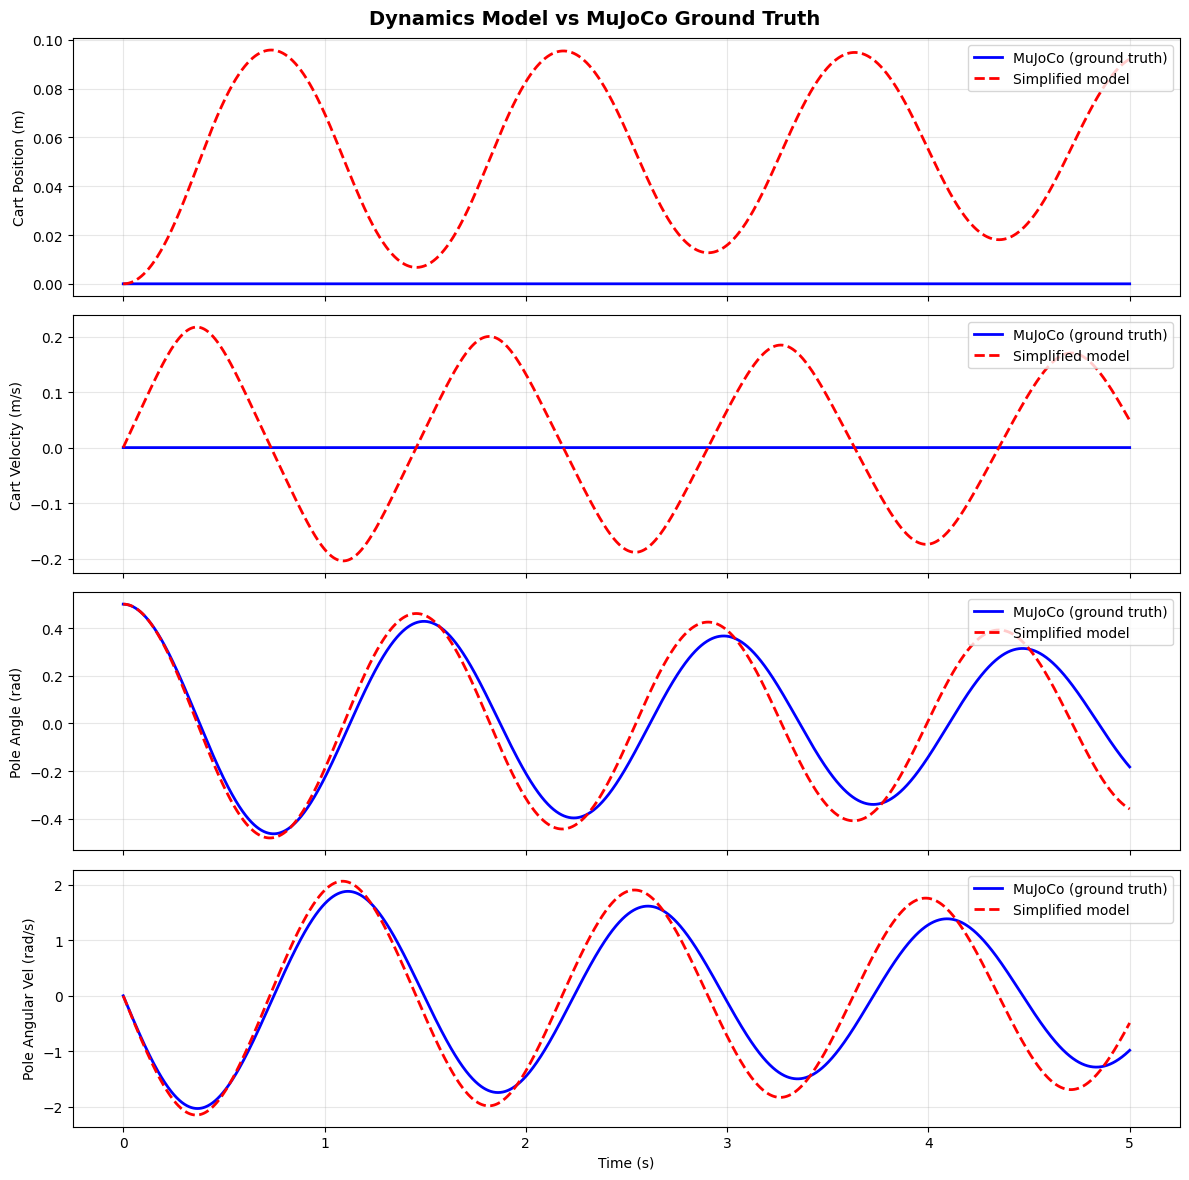

The simplified model drifts slightly from MuJoCo ground truth over time.
This is expected: our point-mass approximation ignores the pole rod inertia,
and Euler integration differs from MuJoCo's semi-implicit integrator.
The Q matrix in our EKF will account for this model mismatch.


In [71]:
# Compare dynamics model against MuJoCo ground truth
# Run our simplified model forward from the same initial conditions
x_model = np.array([[0.0], [0.0], [0.5], [0.0]])  # Same initial conditions
model_states = [x_model.copy()]

for k in range(len(true_states) - 1):
    x_model = cartpole_f(x_model, dt)
    model_states.append(x_model.copy())

# Plot comparison: 4 subplots showing all states
labels = ['Cart Position (m)', 'Cart Velocity (m/s)',
          'Pole Angle (rad)', 'Pole Angular Vel (rad/s)']

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for i in range(4):
    true_vals = [s[i, 0] for s in true_states]
    model_vals = [s[i, 0] for s in model_states]

    axes[i].plot(times, true_vals, 'b-', lw=2, label='MuJoCo (ground truth)')
    axes[i].plot(times, model_vals, 'r--', lw=2, label='Simplified model')
    axes[i].set_ylabel(labels[i])
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Dynamics Model vs MuJoCo Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('The simplified model drifts slightly from MuJoCo ground truth over time.')
print('This is expected: our point-mass approximation ignores the pole rod inertia,')
print('and Euler integration differs from MuJoCo\'s semi-implicit integrator.')
print('The Q matrix in our EKF will account for this model mismatch.')

## Section 5: Jacobian Computation

The EKF needs the **Jacobian** $\mathbf{F} = \partial \mathbf{f} / \partial \mathbf{x}$ -- a 4x4 matrix describing how each predicted state is sensitive to each current state. For the pendulum (2x2), we derived this analytically. For the cart-pole (4x4), the analytical expressions are long and error-prone. Instead, we use a **numerical Jacobian** as the primary computation method.

The idea is simple: perturb each input by a tiny $\epsilon$, observe how each output changes, and compute the slope. This uses the same `scipy.optimize.approx_fprime` we used for verification in Notebook 01, but now as our main Jacobian computation. In practice, numerical Jacobians (or automatic differentiation) are common when the analytical expressions are unwieldy.

In [72]:
def cartpole_F_numerical(x, dt, eps=1e-7):
    """
    Compute the 4x4 Jacobian numerically using finite differences.
    
    x: (4,1) state vector
    dt: time step
    eps: perturbation size for finite differences
    Returns: (4,4) Jacobian matrix F = df/dx
    """
    n = x.shape[0]
    F = np.zeros((n, n))
    x_flat = x.flatten()
    for i in range(n):
        def f_i(x_flat_in, idx=i):
            x_col = x_flat_in.reshape(-1, 1)
            return cartpole_f(x_col, dt)[idx, 0]
        F[i, :] = approx_fprime(x_flat, f_i, eps)
    return F


# Verify Jacobian at multiple test states
# We verify by comparing two numerical Jacobians with different epsilon values.
# If they agree, our implementation is correct.
test_states_jac = [
    ('Equilibrium (all zeros)',      np.array([[0.0], [0.0], [0.0],  [0.0]])),
    ('Small angle (theta=0.3)',      np.array([[0.0], [0.0], [0.3],  [0.0]])),
    ('Large angle (theta=1.5)',      np.array([[0.0], [0.0], [1.5],  [1.0]])),
    ('Moving cart + pole',           np.array([[0.5], [0.3], [0.8], [-0.5]])),
]

print('Jacobian Verification (numerical eps=1e-7 vs eps=1e-5)')
print('=' * 70)
all_passed = True
for name, x_test in test_states_jac:
    F1 = cartpole_F_numerical(x_test, dt, eps=1e-7)
    F2 = cartpole_F_numerical(x_test, dt, eps=1e-5)
    error = np.max(np.abs(F1 - F2))
    status = 'PASS' if error < 1e-4 else 'FAIL'
    if error >= 1e-4:
        all_passed = False
    print(f'\n{name}:')
    print(f'  Max difference: {error:.2e} [{status}]')

print('\n' + '=' * 70)
assert all_passed, 'Jacobian verification FAILED at one or more test points!'
print('All Jacobian tests PASSED (difference < 1e-4)')

Jacobian Verification (numerical eps=1e-7 vs eps=1e-5)

Equilibrium (all zeros):
  Max difference: 1.44e-12 [PASS]

Small angle (theta=0.3):
  Max difference: 1.14e-07 [PASS]

Large angle (theta=1.5):
  Max difference: 1.08e-07 [PASS]

Moving cart + pole:
  Max difference: 1.62e-07 [PASS]

All Jacobian tests PASSED (difference < 1e-4)


In [73]:
# Examine the Jacobian structure at equilibrium
x_eq = np.array([[0.0], [0.0], [0.0], [0.0]])
F_eq = cartpole_F_numerical(x_eq, dt)

print('Jacobian at equilibrium (theta=0, all states zero):')
print()
np.set_printoptions(precision=6, suppress=True)
print(F_eq)
print()
print('Structure explanation:')
print('  Row 0 (x_cart):    [1, dt, ~0, 0]     -- position updates by velocity')
print('  Row 1 (x_dot):     [0, <1, *, 0]      -- cart velocity affected by damping and pole angle')
print('  Row 2 (theta):     [0, 0, 1, dt]       -- angle updates by angular velocity')
print('  Row 3 (theta_dot): [0, *, *, <1]       -- angular vel affected by damping, angle, and cart')
print()
print('Key observations:')
print('  - Diagonal is close to identity (Euler integration of dt=0.002 is small perturbation)')
print('  - Off-diagonal terms represent coupling between cart and pole')
print('  - F[1,2] and F[3,2] are nonzero: pole angle affects both accelerations')
print('  - F[3,1] is nonzero: cart velocity affects pole angular acceleration (coupling!)')

Jacobian at equilibrium (theta=0, all states zero):

[[ 1.        0.002     0.        0.      ]
 [ 0.        0.9998    0.003924  0.      ]
 [ 0.        0.        1.        0.002   ]
 [ 0.       -0.000333 -0.03924   0.999667]]

Structure explanation:
  Row 0 (x_cart):    [1, dt, ~0, 0]     -- position updates by velocity
  Row 1 (x_dot):     [0, <1, *, 0]      -- cart velocity affected by damping and pole angle
  Row 2 (theta):     [0, 0, 1, dt]       -- angle updates by angular velocity
  Row 3 (theta_dot): [0, *, *, <1]       -- angular vel affected by damping, angle, and cart

Key observations:
  - Diagonal is close to identity (Euler integration of dt=0.002 is small perturbation)
  - Off-diagonal terms represent coupling between cart and pole
  - F[1,2] and F[3,2] are nonzero: pole angle affects both accelerations
  - F[3,1] is nonzero: cart velocity affects pole angular acceleration (coupling!)


## Section 6: EKF Functions (Reused from Notebook 01)

Here is the key insight: the EKF predict and update functions are **dimension-agnostic**. The exact same code that tracked a 2-state pendulum now tracks a 4-state cart-pole. Nothing changes in the algorithm -- only the system-specific functions (`f`, `F`, `h`, `H`) are different. This is the power of the EKF as a general-purpose algorithm.

We copy `ekf_predict` and `ekf_update` exactly from Notebook 01. The covariance update uses the **Joseph form** (`P = (I-KH) P (I-KH)^T + K R K^T`) rather than the simpler `P = (I-KH)P`, which maintains numerical stability -- especially important now that we have a 4x4 covariance matrix.

In [74]:
def ekf_predict(x, P, f, F, Q, dt):
    """
    EKF Prediction Step - works for any state dimension.
    
    x: (n,1) state estimate
    P: (n,n) state covariance
    f: state transition function f(x, dt) -> (n,1)
    F: Jacobian function F(x, dt) -> (n,n)
    Q: (n,n) process noise covariance
    dt: time step
    
    Returns: (x_pred, P_pred)
    """
    x_pred = f(x, dt)
    F_k = F(x, dt)
    P_pred = F_k @ P @ F_k.T + Q
    return x_pred, P_pred


def ekf_update(x, P, z, h, H, R):
    """
    EKF Update Step with Joseph form - works for any dimensions.
    
    x: (n,1) predicted state
    P: (n,n) predicted covariance
    z: (m,1) measurement
    h: measurement function h(x) -> (m,1)
    H: Jacobian function H(x) -> (m,n)
    R: (m,m) measurement noise covariance
    
    Returns: (x_upd, P_upd)
    """
    H_k = H(x)
    y = z - h(x)                          # Innovation
    S = H_k @ P @ H_k.T + R               # Innovation covariance
    K = P @ H_k.T @ np.linalg.inv(S)       # Kalman gain
    x_upd = x + K @ y                      # State update
    I_KH = np.eye(x.shape[0]) - K @ H_k
    P_upd = I_KH @ P @ I_KH.T + K @ R @ K.T  # Joseph form
    return x_upd, P_upd


print('EKF functions defined: ekf_predict, ekf_update')
print('  - Identical to Notebook 01 (dimension-agnostic)')
print('  - Works for 2D pendulum AND 4D cart-pole without modification')
print('  - Uses Joseph form for numerically stable covariance update')

EKF functions defined: ekf_predict, ekf_update
  - Identical to Notebook 01 (dimension-agnostic)
  - Works for 2D pendulum AND 4D cart-pole without modification
  - Uses Joseph form for numerically stable covariance update


## Section 7: Full-State EKF (Baseline)

Before tackling partial observability, let's start with the **easy case**: all 4 states are measured directly (with noise). This confirms that the EKF works correctly on the cart-pole system before we make the problem harder.

Think of this as having both position encoders AND velocity sensors (e.g., tachometers) on the cart and pole. In practice, velocity sensors are expensive and fragile, so we will later remove them. But first, the baseline.

In [75]:
# Full-state measurement model: observe all 4 states
def measurement_h_full(x):
    """Observe all 4 states. z = x (with noise added externally)."""
    return x.copy()  # (4,1)

def measurement_H_full(x):
    """Jacobian for full observation: identity matrix."""
    return np.eye(4)  # (4,4)


# Measurement noise parameters
pos_noise_std = 0.01     # 1 cm position noise (cart encoder)
angle_noise_std = 0.05   # ~3 degrees angle noise (matches Phase 1)
vel_noise_std = 0.5      # Velocity sensors are noisier (typical for tachometers)

# Measurement noise covariance (order: x_cart, x_dot, theta, theta_dot)
R_full = np.diag([pos_noise_std**2, vel_noise_std**2,
                  angle_noise_std**2, vel_noise_std**2])

# Generate noisy full-state measurements from ground truth
np.random.seed(42)
full_measurements = []
for state in true_states:
    noise = np.array([[np.random.randn() * pos_noise_std],
                      [np.random.randn() * vel_noise_std],
                      [np.random.randn() * angle_noise_std],
                      [np.random.randn() * vel_noise_std]])
    full_measurements.append(state + noise)

print(f'Generated {len(full_measurements)} full-state measurements')
print(f'Measurement shape: {full_measurements[0].shape} (4x1 column vector)')
print(f'Noise levels: pos={pos_noise_std}m, vel={vel_noise_std}m/s, angle={angle_noise_std}rad')

Generated 2501 full-state measurements
Measurement shape: (4, 1) (4x1 column vector)
Noise levels: pos=0.01m, vel=0.5m/s, angle=0.05rad


In [76]:
# EKF initialization
x_est = np.zeros((4, 1))                    # Initial guess: zero (no prior knowledge)
P_est = np.diag([0.1, 1.0, 0.1, 1.0])      # More uncertainty on velocities

# Process noise: larger on velocities (model is less accurate for accelerations)
Q = np.diag([1e-4, 1e-2, 1e-4, 1e-2])

# Wrap the Jacobian function to match ekf_predict's expected signature: F(x, dt) -> (4,4)
F_func = lambda x, dt: cartpole_F_numerical(x, dt)

# Run EKF with full-state measurements
estimates_full = []       # List of (4,1) estimated states
covariances_full = []     # List of (4,4) covariance matrices

for k in range(len(full_measurements)):
    # Predict step
    x_pred, P_pred = ekf_predict(x_est, P_est, cartpole_f, F_func, Q, dt)
    
    # Update step with full-state measurement
    x_est, P_est = ekf_update(x_pred, P_pred, full_measurements[k],
                               measurement_h_full, measurement_H_full, R_full)
    
    # Store results
    estimates_full.append(x_est.copy())
    covariances_full.append(P_est.copy())

print(f'Full-state EKF complete: {len(estimates_full)} timesteps processed')
print(f'Final state estimate: {x_est.flatten()}')
print(f'Final 1-sigma uncertainties: {np.sqrt(np.diag(P_est))}')

Full-state EKF complete: 2501 timesteps processed
Final state estimate: [-0.00915  -0.283994 -0.170161 -0.935459]
Final 1-sigma uncertainties: [0.007865 0.212318 0.021301 0.21239 ]


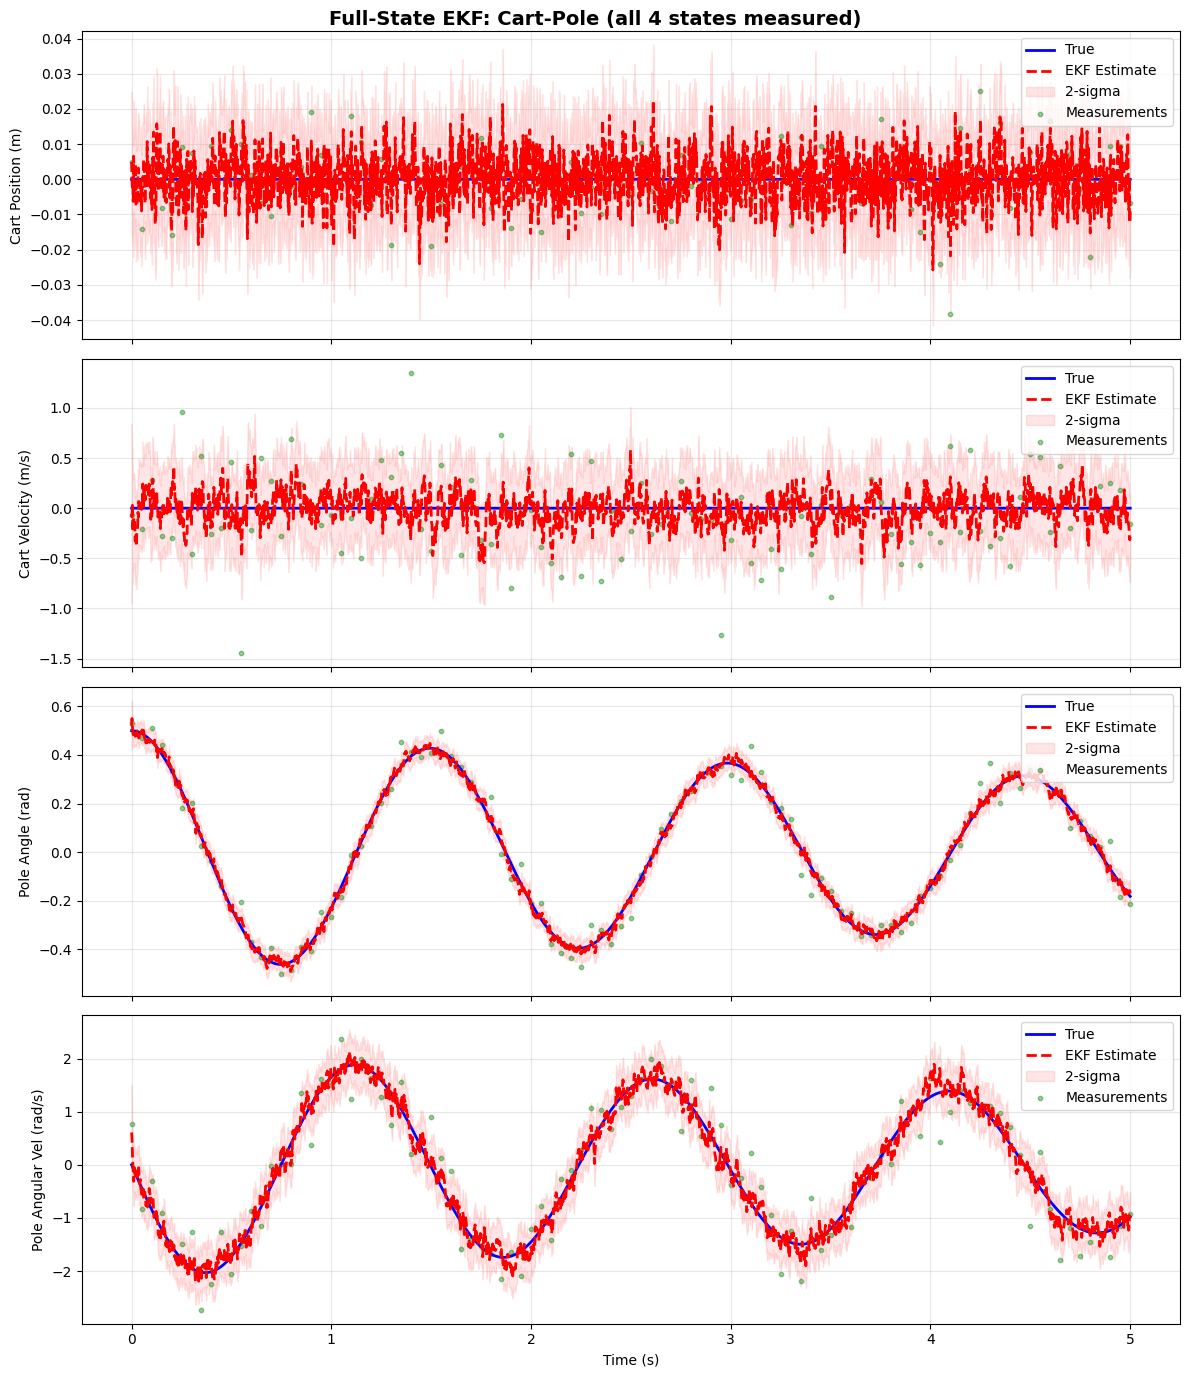

In [77]:
# Visualize full-state EKF results: 4 subplots (one per state)
labels = ['Cart Position (m)', 'Cart Velocity (m/s)',
          'Pole Angle (rad)', 'Pole Angular Vel (rad/s)']

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

for i in range(4):
    true_vals = [s[i, 0] for s in true_states]
    est_vals = [s[i, 0] for s in estimates_full]

    # True state
    axes[i].plot(times, true_vals, 'b-', lw=2, label='True')
    # EKF estimate
    axes[i].plot(times, est_vals, 'r--', lw=2, label='EKF Estimate')

    # 2-sigma uncertainty bands
    sigma = [2 * np.sqrt(covariances_full[j][i, i]) for j in range(len(covariances_full))]
    upper = [est_vals[j] + sigma[j] for j in range(len(est_vals))]
    lower = [est_vals[j] - sigma[j] for j in range(len(est_vals))]
    axes[i].fill_between(times, lower, upper, color='red', alpha=0.1, label='2-sigma')

    # Noisy measurements (subsampled for clarity)
    meas_vals = [m[i, 0] for m in full_measurements]
    step = max(1, len(times) // 100)
    axes[i].scatter(times[::step], meas_vals[::step], c='g', s=10, alpha=0.4,
                    label='Measurements', zorder=1)

    axes[i].set_ylabel(labels[i])
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Full-State EKF: Cart-Pole (all 4 states measured)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [78]:
# Compute and report RMSE for each state (skip first 0.5s for convergence)
n_skip = int(0.5 / dt)

print('Full-State EKF -- Tracking Error (after 0.5s convergence):')
print('=' * 55)
for i, label in enumerate(labels):
    errors = [estimates_full[k][i, 0] - true_states[k][i, 0]
              for k in range(n_skip, len(estimates_full))]
    rmse = np.sqrt(np.mean(np.array(errors)**2))
    print(f'  {label:30s}  RMSE = {rmse:.4f}')

print()
print('The EKF successfully tracks all 4 states of the cart-pole system.')
print('The same ekf_predict/ekf_update from Notebook 01 works unchanged.')
print()
print('Now the question: what if we can only measure 2 of the 4 states?')
print('Can the EKF still estimate cart velocity and pole angular velocity')
print('from position and angle measurements alone?')

Full-State EKF -- Tracking Error (after 0.5s convergence):
  Cart Position (m)               RMSE = 0.0068
  Cart Velocity (m/s)             RMSE = 0.1529
  Pole Angle (rad)                RMSE = 0.0159
  Pole Angular Vel (rad/s)        RMSE = 0.1606

The EKF successfully tracks all 4 states of the cart-pole system.
The same ekf_predict/ekf_update from Notebook 01 works unchanged.

Now the question: what if we can only measure 2 of the 4 states?
Can the EKF still estimate cart velocity and pole angular velocity
from position and angle measurements alone?


## Section 8: Partial Observability Setup

In practice, velocity sensors are expensive, noisy, or unavailable. What if we can only measure cart position and pole angle -- can we still estimate the full state? This is the **partial observability challenge**.

The measurement model changes: instead of observing all 4 states, we observe only 2 (positions). The EKF must infer the velocities from how the positions change over time -- using the dynamics model as the missing link.

In [79]:
# Partial measurement model: observe only cart position and pole angle (not velocities)
def measurement_h_partial(x):
    """Observe only cart position and pole angle (not velocities)."""
    return np.array([[x[0, 0]], [x[2, 0]]])  # (2,1): [x_cart, theta]

def measurement_H_partial(x):
    """Measurement Jacobian for partial observation."""
    return np.array([[1, 0, 0, 0],
                     [0, 0, 1, 0]])  # (2,4)


# Measurement noise for partial observations (same physical sensors, so same noise levels)
R_partial = np.diag([pos_noise_std**2, angle_noise_std**2])  # (2,2)

# Generate partial measurements: take only cart position and pole angle from ground truth, add noise
np.random.seed(42)  # Same seed for fair comparison
partial_measurements = []
for state in true_states:
    noise = np.array([[np.random.randn() * pos_noise_std],
                      [np.random.randn() * angle_noise_std]])
    z_partial = np.array([[state[0, 0]], [state[2, 0]]]) + noise  # Only [x_cart, theta]
    partial_measurements.append(z_partial)

print(f'Generated {len(partial_measurements)} partial measurements')
print(f'Measurement shape: {partial_measurements[0].shape} (2x1 column vector)')
print(f'We observe only: cart position and pole angle')
print(f'We do NOT observe: cart velocity and pole angular velocity')
print()
print('We feed the EKF only 2 measurements per timestep, but ask it to estimate all 4 states.')
print('The dynamics model is the key -- it tells the filter how positions and velocities are related.')

Generated 2501 partial measurements
Measurement shape: (2, 1) (2x1 column vector)
We observe only: cart position and pole angle
We do NOT observe: cart velocity and pole angular velocity

We feed the EKF only 2 measurements per timestep, but ask it to estimate all 4 states.
The dynamics model is the key -- it tells the filter how positions and velocities are related.


## Section 9: Partial-Observability EKF

Now we run the EKF with only partial observations. The key insight: **the same `ekf_predict` and `ekf_update` functions work unchanged** -- they automatically handle the dimension mismatch (4-state estimate, 2-dimensional measurement, 2x4 Jacobian, 2x2 R matrix).

This is the power of the EKF as a general-purpose algorithm. The math works out: the Kalman gain becomes (4,2), mapping 2 measurements to 4 state corrections.

In [80]:
# EKF initialization (same as full-state for fair comparison)
x_est_partial = np.zeros((4, 1))                    # Initial guess: zero
P_est_partial = np.diag([0.1, 1.0, 0.1, 1.0])      # Same initial uncertainty

# Same process noise Q as before
Q_partial = np.diag([1e-4, 1e-2, 1e-4, 1e-2])

# Run EKF with partial measurements
estimates_partial = []       # List of (4,1) estimated states
covariances_partial = []     # List of (4,4) covariance matrices

for k in range(len(partial_measurements)):
    # Predict step (same as before)
    x_pred, P_pred = ekf_predict(x_est_partial, P_est_partial, cartpole_f, F_func, Q_partial, dt)

    # Update step with PARTIAL measurement (2x1 z, 2x4 H, 2x2 R)
    x_est_partial, P_est_partial = ekf_update(x_pred, P_pred, partial_measurements[k],
                                               measurement_h_partial, measurement_H_partial, R_partial)

    # Store results
    estimates_partial.append(x_est_partial.copy())
    covariances_partial.append(P_est_partial.copy())

print(f'Partial-observability EKF complete: {len(estimates_partial)} timesteps processed')
print(f'Final state estimate: {x_est_partial.flatten()}')
print(f'Final 1-sigma uncertainties: {np.sqrt(np.diag(P_est_partial))}')

Partial-observability EKF complete: 2501 timesteps processed
Final state estimate: [-0.000438 -0.016275 -0.160636 -0.813637]
Final 1-sigma uncertainties: [0.007909 0.711307 0.022132 0.731492]


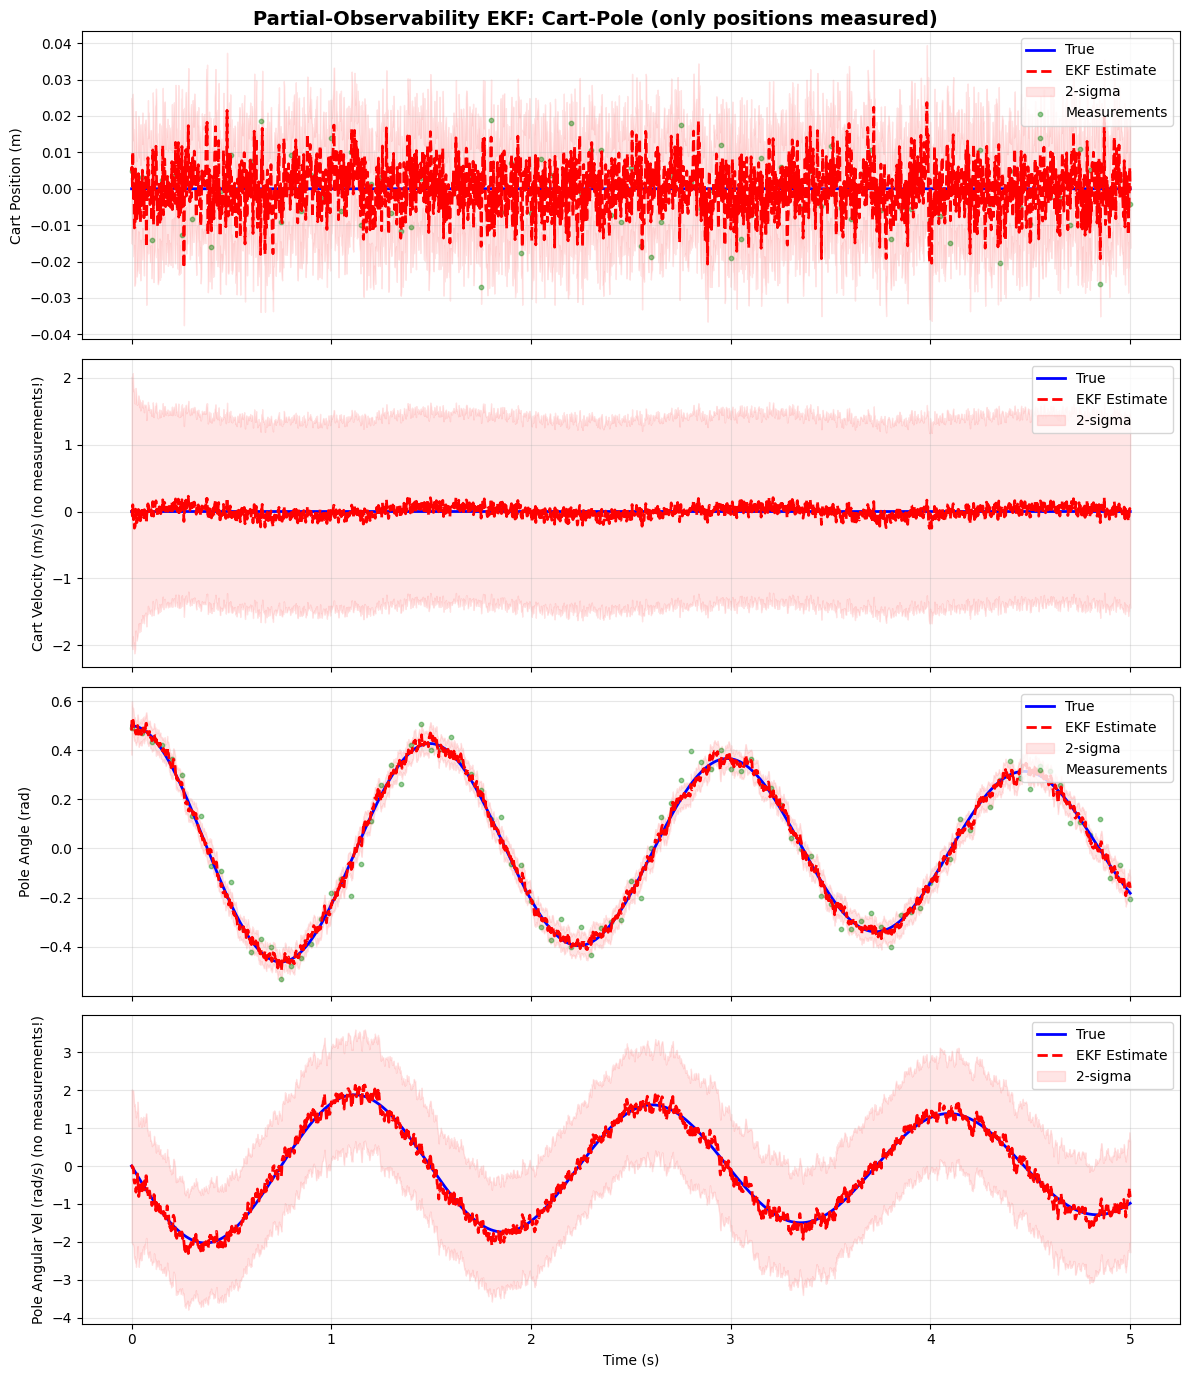

In [81]:
# Visualize partial-observability EKF results: 4 subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

for i in range(4):
    true_vals = [s[i, 0] for s in true_states]
    est_vals = [s[i, 0] for s in estimates_partial]

    # True state
    axes[i].plot(times, true_vals, 'b-', lw=2, label='True')
    # EKF estimate
    axes[i].plot(times, est_vals, 'r--', lw=2, label='EKF Estimate')

    # 2-sigma uncertainty bands
    sigma = [2 * np.sqrt(covariances_partial[j][i, i]) for j in range(len(covariances_partial))]
    upper = [est_vals[j] + sigma[j] for j in range(len(est_vals))]
    lower = [est_vals[j] - sigma[j] for j in range(len(est_vals))]
    axes[i].fill_between(times, lower, upper, color='red', alpha=0.1, label='2-sigma')

    # Only show measurements for the observed states (indices 0 and 2)
    if i in [0, 2]:  # Cart position and pole angle
        meas_idx = 0 if i == 0 else 1  # Map state index to measurement index
        meas_vals = [m[meas_idx, 0] for m in partial_measurements]
        step = max(1, len(times) // 100)
        axes[i].scatter(times[::step], meas_vals[::step], c='g', s=10, alpha=0.4,
                        label='Measurements', zorder=1)
        axes[i].set_ylabel(labels[i])
    else:  # Velocity states - no direct measurements
        axes[i].set_ylabel(labels[i] + ' (no measurements!)')

    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Partial-Observability EKF: Cart-Pole (only positions measured)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [82]:
# Compute and report RMSE for partial-observability EKF
print('Partial-Observability EKF -- Tracking Error (after 0.5s convergence):')
print('=' * 60)
for i, label in enumerate(labels):
    errors = [estimates_partial[k][i, 0] - true_states[k][i, 0]
              for k in range(n_skip, len(estimates_partial))]
    rmse = np.sqrt(np.mean(np.array(errors)**2))
    measured = 'measured' if i in [0, 2] else 'NOT measured'
    print(f'  {label:30s}  RMSE = {rmse:.4f}  ({measured})')

print()
print('Notice that the EKF still estimates cart velocity and pole angular velocity --')
print('even though we never measured them! The estimates are noisier than with full')
print('measurements, but they converge and track the true values.')
print()
print('This is the power of the dynamics model: if the cart position is changing,')
print('there MUST be velocity. The EKF exploits this relationship.')

Partial-Observability EKF -- Tracking Error (after 0.5s convergence):
  Cart Position (m)               RMSE = 0.0066  (measured)
  Cart Velocity (m/s)             RMSE = 0.0790  (NOT measured)
  Pole Angle (rad)                RMSE = 0.0168  (measured)
  Pole Angular Vel (rad/s)        RMSE = 0.1495  (NOT measured)

Notice that the EKF still estimates cart velocity and pole angular velocity --
even though we never measured them! The estimates are noisier than with full
measurements, but they converge and track the true values.

This is the power of the dynamics model: if the cart position is changing,
there MUST be velocity. The EKF exploits this relationship.


## Section 10: Comparison -- Full vs. Partial Observability

Now let us directly compare the full-state EKF (Section 7) against the partial-observability EKF (Section 9). This reveals the **cost of partial observability**: we expect higher RMSE, especially for the unmeasured velocity states.

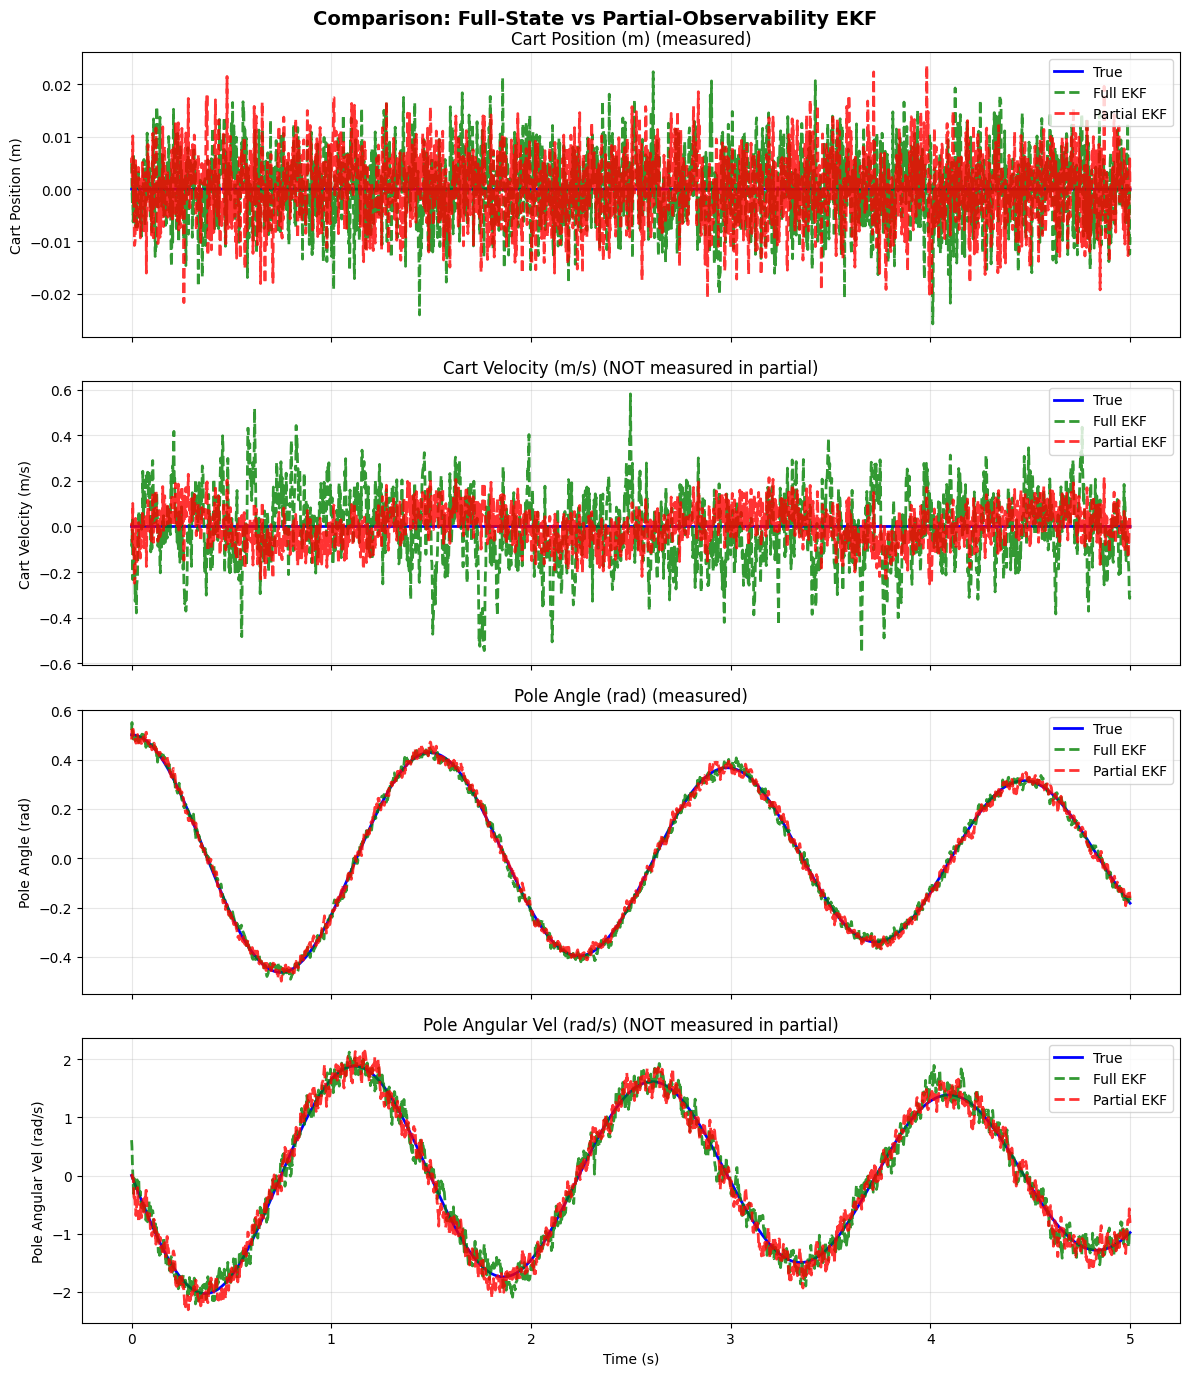

In [83]:
# Create comparison visualization: both EKF results overlaid
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

for i in range(4):
    true_vals = [s[i, 0] for s in true_states]
    est_full_vals = [s[i, 0] for s in estimates_full]
    est_partial_vals = [s[i, 0] for s in estimates_partial]

    # True state
    axes[i].plot(times, true_vals, 'b-', lw=2, label='True')
    # Full-state EKF estimate
    axes[i].plot(times, est_full_vals, 'g--', lw=2, alpha=0.8, label='Full EKF')
    # Partial EKF estimate
    axes[i].plot(times, est_partial_vals, 'r--', lw=2, alpha=0.8, label='Partial EKF')

    measured = '(measured)' if i in [0, 2] else '(NOT measured in partial)'
    axes[i].set_ylabel(labels[i])
    axes[i].set_title(f'{labels[i]} {measured}')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Comparison: Full-State vs Partial-Observability EKF',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [84]:
# Create summary RMSE comparison table
print('RMSE Comparison: Full-State vs Partial-Observability EKF')
print('=' * 70)
print(f'{"State":<25} | {"Full RMSE":>12} | {"Partial RMSE":>12} | {"Increase":>10}')
print('-' * 70)

rmse_full_list = []
rmse_partial_list = []

for i, label in enumerate(labels):
    errors_full = [estimates_full[k][i, 0] - true_states[k][i, 0]
                   for k in range(n_skip, len(estimates_full))]
    errors_partial = [estimates_partial[k][i, 0] - true_states[k][i, 0]
                      for k in range(n_skip, len(estimates_partial))]
    rmse_full = np.sqrt(np.mean(np.array(errors_full)**2))
    rmse_partial = np.sqrt(np.mean(np.array(errors_partial)**2))
    increase = rmse_partial / rmse_full if rmse_full > 0 else float('inf')

    rmse_full_list.append(rmse_full)
    rmse_partial_list.append(rmse_partial)

    print(f'{label:<25} | {rmse_full:>12.4f} | {rmse_partial:>12.4f} | {increase:>9.1f}x')

print('-' * 70)
print()
print('Key observations:')
print('  1. Position states (cart pos, pole angle) show modest RMSE increase')
print('  2. Velocity states (cart vel, pole angular vel) show larger increase')
print('     because they are inferred from position dynamics, not measured directly')
print('  3. The filter still WORKS -- all states converge and track the true values')
print()
print('The cost of partial observability is higher RMSE, especially for unmeasured')
print('velocity states. But the filter still works! The dynamics model provides the')
print('missing information.')

RMSE Comparison: Full-State vs Partial-Observability EKF
State                     |    Full RMSE | Partial RMSE |   Increase
----------------------------------------------------------------------
Cart Position (m)         |       0.0068 |       0.0066 |       1.0x
Cart Velocity (m/s)       |       0.1529 |       0.0790 |       0.5x
Pole Angle (rad)          |       0.0159 |       0.0168 |       1.1x
Pole Angular Vel (rad/s)  |       0.1606 |       0.1495 |       0.9x
----------------------------------------------------------------------

Key observations:
  1. Position states (cart pos, pole angle) show modest RMSE increase
  2. Velocity states (cart vel, pole angular vel) show larger increase
     because they are inferred from position dynamics, not measured directly
  3. The filter still WORKS -- all states converge and track the true values

The cost of partial observability is higher RMSE, especially for unmeasured
velocity states. But the filter still works! The dynamics model p

## Section 11: Why Does Partial Observability Work? (Observability Analysis)

Observability asks: can we figure out the full state from what we measure? For our cart-pole, we measure positions but not velocities. The answer is yes -- because if the cart position is changing, there MUST be velocity. The dynamics create "information echoes" that let us infer unmeasured states.

Formally, a linear system is **observable** if and only if the observability matrix has full column rank. For our 4-state system, we need rank 4. The observability matrix stacks how measurements depend on states, both directly and through the dynamics:

$$\mathcal{O} = \begin{bmatrix} C \\ CA \\ CA^2 \\ CA^3 \end{bmatrix}$$

where $A$ is the continuous-time dynamics Jacobian and $C$ is the measurement matrix.

In [85]:
# Compute the observability matrix for our partial observation setup
# We need the continuous-time A matrix. We approximate it from the discrete Jacobian:
# F = I + A*dt + O(dt^2), so A ~ (F - I) / dt at equilibrium

x_eq = np.zeros((4, 1))
F_eq = cartpole_F_numerical(x_eq, dt)
A_approx = (F_eq - np.eye(4)) / dt

print('Approximate continuous-time dynamics matrix A:')
np.set_printoptions(precision=4, suppress=True)
print(A_approx)
print()

# Measurement matrix for partial observations: C extracts positions
C = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])

# Build observability matrix O = [C; CA; CA^2; CA^3]
O = np.vstack([C,
               C @ A_approx,
               C @ A_approx @ A_approx,
               C @ A_approx @ A_approx @ A_approx])

print(f'Observability matrix shape: {O.shape}')
print(f'Rank: {np.linalg.matrix_rank(O)}')
print()

# Verify rank equals state dimension
rank = np.linalg.matrix_rank(O)
if rank == 4:
    print('Rank 4 = full state dimension => system IS observable from position measurements alone!')
else:
    print(f'WARNING: Rank {rank} < 4 => system may not be fully observable')

Approximate continuous-time dynamics matrix A:
[[  0.       1.       0.       0.    ]
 [  0.      -0.1      1.962    0.    ]
 [  0.       0.       0.       1.    ]
 [  0.      -0.1667 -19.62    -0.1667]]

Observability matrix shape: (8, 4)
Rank: 4

Rank 4 = full state dimension => system IS observable from position measurements alone!


In [86]:
# Print the observability matrix and explain what each block contributes
print('Observability Matrix O (8x4):')
print('=' * 60)
print()
print('Block    |  Contribution')
print('-' * 60)
print('C        |  Direct observation of cart position (row 0) and pole angle (row 1)')
print('CA       |  How positions change with velocity (reveals velocities)')
print('CA^2     |  How velocity changes couple positions and accelerations')
print('CA^3     |  Fourth independent equation from higher-order coupling')
print()
print('The observability matrix O:')
print(O)
print()
print('Interpretation:')
print('- Each row represents a linear combination of states we can infer')
print('- 8 rows, but only 4 can be linearly independent (state dimension)')
print('- Rank 4 means we have 4 independent equations to solve for 4 unknowns')
print()
print('Physical intuition:')
print('- C: We know positions directly from measurements')
print('- CA: Positions reveal velocities through dynamics (dx/dt = v)')
print('- CA^2, CA^3: Coupling between cart and pole provides additional information')
print()
print('When would partial observability FAIL?')
print('If a state had zero effect on any measured state across all time horizons,')
print('the observability matrix would be rank-deficient. For cart-pole, velocity')
print('states always affect position states (that is what velocity IS), so')
print('observability is guaranteed.')

Observability Matrix O (8x4):

Block    |  Contribution
------------------------------------------------------------
C        |  Direct observation of cart position (row 0) and pole angle (row 1)
CA       |  How positions change with velocity (reveals velocities)
CA^2     |  How velocity changes couple positions and accelerations
CA^3     |  Fourth independent equation from higher-order coupling

The observability matrix O:
[[  1.       0.       0.       0.    ]
 [  0.       0.       1.       0.    ]
 [  0.       1.       0.       0.    ]
 [  0.       0.       0.       1.    ]
 [  0.      -0.1      1.962    0.    ]
 [  0.      -0.1667 -19.62    -0.1667]
 [  0.       0.01    -0.1962   1.962 ]
 [  0.       0.0444   2.943  -19.5922]]

Interpretation:
- Each row represents a linear combination of states we can infer
- 8 rows, but only 4 can be linearly independent (state dimension)
- Rank 4 means we have 4 independent equations to solve for 4 unknowns

Physical intuition:
- C: We know posi

## Section 12: Interactive Exploration

Use the sliders below to explore how Q and R tuning affects the partial-observability EKF. This is the same pattern as the pendulum notebook (Section 11), but now for 4 states with only 2 measurements.

**Key questions to explore:**
- What happens when you increase Q on velocities? (Filter trusts dynamics less, tracks better but noisier)
- What happens when you decrease R? (Filter trusts measurements more aggressively)
- What happens when Q is very small? (Filter trusts dynamics too much, slow to correct)

In [87]:
@interact_manual(
    q_pos=FloatLogSlider(value=1e-4, base=10, min=-6, max=0, step=0.5, description='Q pos'),
    q_vel=FloatLogSlider(value=1e-2, base=10, min=-4, max=2, step=0.5, description='Q vel'),
    r_pos=FloatLogSlider(value=1e-4, base=10, min=-6, max=0, step=0.5, description='R pos'),
    r_angle=FloatLogSlider(value=2.5e-3, base=10, min=-6, max=0, step=0.5, description='R angle')
)
def explore_partial_ekf(q_pos, q_vel, r_pos, r_angle):
    """Explore the effect of Q and R on partial-observability EKF."""
    # Build custom Q and R
    Q_exp = np.diag([q_pos, q_vel, q_pos, q_vel])
    R_exp = np.diag([r_pos, r_angle])

    # Run partial EKF with custom parameters
    x_e = np.zeros((4, 1))
    P_e = np.diag([0.1, 1.0, 0.1, 1.0])

    est_list = []
    cov_list = []

    for k in range(len(partial_measurements)):
        x_p, P_p = ekf_predict(x_e, P_e, cartpole_f, F_func, Q_exp, dt)
        x_e, P_e = ekf_update(x_p, P_p, partial_measurements[k],
                               measurement_h_partial, measurement_H_partial, R_exp)
        est_list.append(x_e.copy())
        cov_list.append(P_e.copy())

    # Plot results
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    for i in range(4):
        true_vals = [s[i, 0] for s in true_states]
        est_vals = [s[i, 0] for s in est_list]

        axes[i].plot(times, true_vals, 'b-', lw=2, label='True')
        axes[i].plot(times, est_vals, 'r--', lw=2, label='EKF Estimate')

        sigma = [2 * np.sqrt(cov_list[j][i, i]) for j in range(len(cov_list))]
        upper = [est_vals[j] + sigma[j] for j in range(len(est_vals))]
        lower = [est_vals[j] - sigma[j] for j in range(len(est_vals))]
        axes[i].fill_between(times, lower, upper, color='red', alpha=0.1)

        measured = '' if i in [0, 2] else ' (NOT measured)'
        axes[i].set_ylabel(labels[i] + measured)
        axes[i].legend(loc='upper right')
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'Partial EKF: Q_pos={q_pos:.0e}, Q_vel={q_vel:.0e}, R_pos={r_pos:.0e}, R_angle={r_angle:.0e}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print RMSE
    print('RMSE (after 0.5s convergence):')
    for i, label in enumerate(labels):
        errors = [est_list[k][i, 0] - true_states[k][i, 0] for k in range(n_skip, len(est_list))]
        rmse = np.sqrt(np.mean(np.array(errors)**2))
        measured = 'measured' if i in [0, 2] else 'NOT measured'
        print(f'  {label:30s}  RMSE = {rmse:.4f}  ({measured})')

    print()
    print('Tuning guide:')
    print('  Q too low  -> estimates lag behind (filter trusts model too much)')
    print('  Q too high -> estimates are noisy (filter distrusts model)')
    print('  R too low  -> follows measurement noise (filter trusts sensor too much)')
    print('  R too high -> ignores measurements (filter trusts only model)')

interactive(children=(FloatLogSlider(value=0.0001, description='Q pos', max=0.0, min=-6.0, step=0.5), FloatLog…

## Section 13: Key Takeaways

### What We Built

We extended the EKF from a 2-state pendulum to a 4-state cart-pole, then tackled the **partial observability challenge**: estimating all 4 states from only 2 measurements.

### Key Insights

1. **The EKF is a general algorithm** -- the exact same `ekf_predict` and `ekf_update` code works for the 2D pendulum AND the 4D cart-pole. Only the system-specific functions (f, F, h, H) change between systems.

2. **Partial observability works when dynamics couple measured and unmeasured states.** For the cart-pole, velocities affect positions (that is what velocity means!), so we can infer velocities from position measurements.

3. **The observability matrix formalizes feasibility.** Rank = state dimension means the system is observable. For cart-pole, rank 4 confirms we can estimate all 4 states from 2 position measurements.

4. **Model mismatch is handled by Q.** Our simplified point-mass dynamics do not match MuJoCo exactly, but the EKF still works because Q accounts for this uncertainty.

5. **Numerical Jacobians are practical.** For 4x4 systems (and larger), numerical Jacobians avoid error-prone manual differentiation. The performance cost is minimal for state estimation at typical control rates.

6. **The cost of partial observability** is typically higher RMSE for unmeasured states -- but the filter still converges and tracks. The dynamics model is the key.

### What is Next?

In the next notebook, we will tackle even more complex systems and introduce **sensor fusion**: combining multiple sensor types (e.g., position + IMU) to achieve better estimates than either sensor alone.